Mục tiêu: Trả lời **H0₃:** `Median(sum_gamerounds | gate_30) = Median(sum_gamerounds | gate_40)

Ngày thực hiện:2026-08-08

**Step 1:** Import thư viện và cố định seed

In [4]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda v: f'{v:,.4f}')
np.random.seed(42)
print('Environment ready.')

Environment ready.


**STEP 2:** Load mart (SQL Server, fallback CSV replicate policy)

**NOTE**: primary = mart (single source of truth). Fallback CSV phải replicate ĐÚNG policy

(dedup MAX per userid + loại outlier 49854, DEC-03) nếu không số sẽ lệch.

In [5]:
def load_from_sql():    
    import os 
    from dotenv import load_dotenv
    import pyodbc
    load_dotenv()
    conn = pyodbc.connect(
        f"DRIVER={{{os.getenv('DB_DRIVER')}}};"
        f"SERVER={os.getenv('DB_SERVER')};DATABASE={os.getenv('DB_NAME')};"
        f"Trusted_Connection={os.getenv('DB_TRUSTED_CONNECTION','yes')};"
    )
    return pd.read_sql("SELECT * FROM cookie_cats.mart_ab_test_base", conn)

def load_from_csv():
    raw = pd.read_csv('../data/cookie_cats.csv')
    m = (raw.groupby('userid')
            .agg(version=('version','max'), sum_gamerounds=('sum_gamerounds','max'))
            .reset_index())
    return m[m['sum_gamerounds'] != 49854].copy()

try:
    mart = load_from_sql(); SOURCE = 'SQL Server'
except Exception:
    mart = load_from_csv(); SOURCE = 'CSV fallback'
print(f'Source: {SOURCE} | rows: {len(mart):,}')
assert len(mart) == 90188, 'Row count != 90,188 -> mart policy sai, dung kiem tra'
print('Load OK.')

C:\Users\Asus\AppData\Local\Temp\ipykernel_25536\2899147158.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql("SELECT * FROM cookie_cats.mart_ab_test_base", conn)


Source: SQL Server | rows: 90,188
Load OK.


**Step 3:**  Khai báo ngưỡng alpha/Bonferroni và hàm verdict

In [6]:
# NOTE: engagement là 1 trong 3 test đồng thời -> đọc dưới ngưỡng Bonferroni 0.0167 (không phải 0.05)
ALPHA, N_TESTS = 0.05, 3
ALPHA_BONF = ALPHA / N_TESTS
def verdict(p):
    if p < ALPHA_BONF: return 'SIGNIFICANT (vuot Bonferroni)'
    if p < ALPHA:      return 'sig o 0.05, KHONG vuot Bonferroni'
    return 'KHONG significant'
print(f'alpha={ALPHA} | Bonferroni={ALPHA_BONF:.4f}')

alpha=0.05 | Bonferroni=0.0167


**STEP 4:** Thống kê mô tả 2 nhóm -> xác nhận right-skewed (dùng median)

**NOTE:** mean >> median và skew lớn => phân phối lệch phải => KHÔNG dùng mean/t-test

In [8]:
a = mart.loc[mart.version == 'gate_30', 'sum_gamerounds'].values   # control
b = mart.loc[mart.version == 'gate_40', 'sum_gamerounds'].values   # treatment
desc = pd.DataFrame({
    'gate_30': [len(a), np.median(a), a.mean(), stats.skew(a)],
    'gate_40': [len(b), np.median(b), b.mean(), stats.skew(b)],
}, index=['n', 'median', 'mean', 'skew']) 
desc

,gate_30,gate_40
n,"44,699.0000","45,489.0000"
median,17.0000,16.0000
mean,51.3421,51.2988
skew,5.9402,5.9671


**Step 5:** Chạy Mann-Whitney U + rank-biserial effect size

**Note**: Mann-Whitney so rank/phân phối (non-parametric), khớp H0₃ phát biểu theo median.

rank-biserial |r| nhỏ = khác biệt phân phối yếu (bổ sung cho p-value ở n lớn).

In [9]:
U, p_mwu = stats.mannwhitneyu(a, b, alternative='two-sided')
r_rb = 1 - 2 * U / (len(a) * len(b))
print(f'median: gate_30={np.median(a):.0f}  gate_40={np.median(b):.0f}')
print(f'Mann-Whitney U={U:,.0f}  p={p_mwu:.5f}  ->  {verdict(p_mwu)}')
print(f'rank-biserial r={r_rb:+.5f}')

median: gate_30=17  gate_40=16
Mann-Whitney U=1,024,285,762  p=0.05089  ->  KHONG significant
rank-biserial r=-0.00750


**Step 6:** Bootstrap 95% CI cho median difference (treat - control)

**note**: median không có CI closed-form -> resample 10,000 lần; seed=42 để reproducible.

**Quy tắc đọc:** CI CHỨA 0 -> không khác biệt thực tế; KHÔNG chứa 0 -> khác biệt thật.

In [10]:
np.random.seed(42)
B, n1, n2 = 10000, len(a), len(b)
diffs = np.array([np.median(np.random.choice(b, n2, replace=True))
                  - np.median(np.random.choice(a, n1, replace=True)) for _ in range(B)])
ci_lo, ci_hi = np.percentile(diffs, [2.5, 97.5])
contains_zero = ci_lo <= 0 <= ci_hi
print(f'median diff (40-30): mean={diffs.mean():+.3f}  95% CI=[{ci_lo:+.2f}, {ci_hi:+.2f}]')
print('CI chua 0 -> KHONG khac biet thuc te' if contains_zero else 'CI khong chua 0 -> khac biet that')

median diff (40-30): mean=-0.926  95% CI=[-1.00, +0.00]
CI chua 0 -> KHONG khac biet thuc te


**Step 7:** Vẽ phân phối engagement (log scale) + phân phối bootstrap, rồi lư**u file

**Note:** histogram dùng log1p vì đuôi dài; đường median 2 nhóm gần như trùng -> trực quan cho H0₃


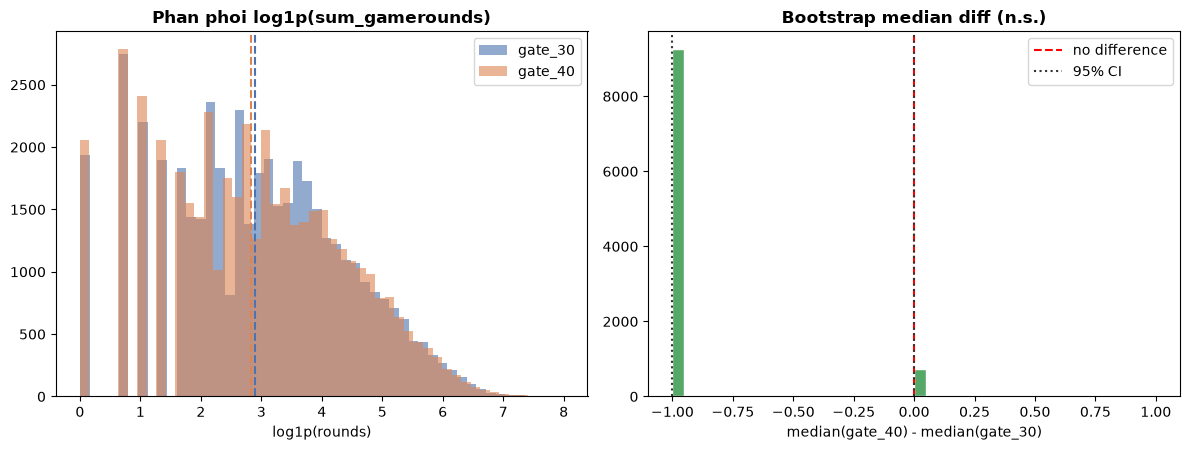

Saved: reports/phase4_g2_engagement.png


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6))
ax1.hist(np.log1p(a), bins=50, alpha=0.6, label='gate_30', color='#4C72B0')
ax1.hist(np.log1p(b), bins=50, alpha=0.6, label='gate_40', color='#DD8452')
ax1.axvline(np.log1p(np.median(a)), color='#4C72B0', ls='--')
ax1.axvline(np.log1p(np.median(b)), color='#DD8452', ls='--')
ax1.set_title('Phan phoi log1p(sum_gamerounds)', fontweight='bold')
ax1.set_xlabel('log1p(rounds)'); ax1.legend()
ax1.grid(False)

ax2.hist(diffs, bins=40, color='#55A868', edgecolor='white')
ax2.axvline(0, color='red', ls='--', lw=1.5, label='no difference')
ax2.axvline(ci_lo, color='#333', ls=':'); ax2.axvline(ci_hi, color='#333', ls=':', label='95% CI')
sig = '***' if p_mwu < ALPHA_BONF else ('*' if p_mwu < ALPHA else 'n.s.')
ax2.set_title(f'Bootstrap median diff ({sig})', fontweight='bold')
ax2.set_xlabel('median(gate_40) - median(gate_30)'); ax2.legend()
ax2.grid(False)

fig.tight_layout()
fig.savefig('../reports/figures/phase4_g2_engagement.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: reports/phase4_g2_engagement.png')